In [2]:
import thinkdsp as tk
import matplotlib.pyplot as plt
import ipywidgets as widgets
import scipy.signal
import numpy as np

## Задание 8.2

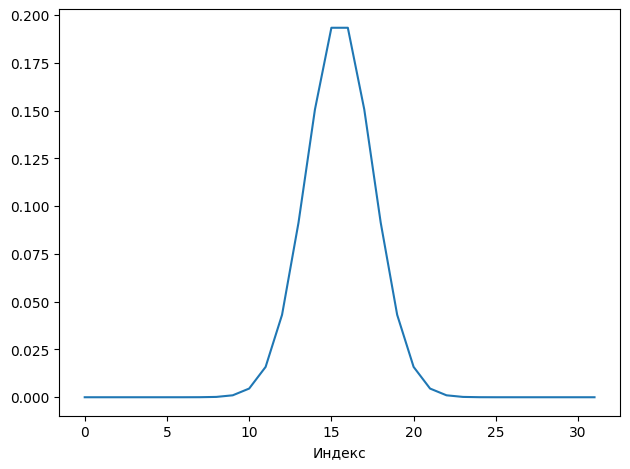

In [3]:
gaussian = scipy.signal.windows.gaussian(M=32, std=2)
gaussian /= sum(gaussian)
plt.plot(gaussian)
tk.decorate(xlabel='Индекс')

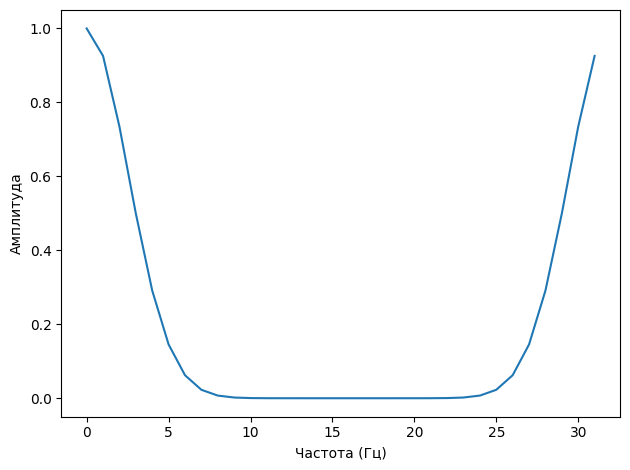

In [4]:
fft_gaussian = np.fft.fft(gaussian)
plt.plot(abs(fft_gaussian))
tk.decorate(xlabel='Частота (Гц)', ylabel='Амплитуда')

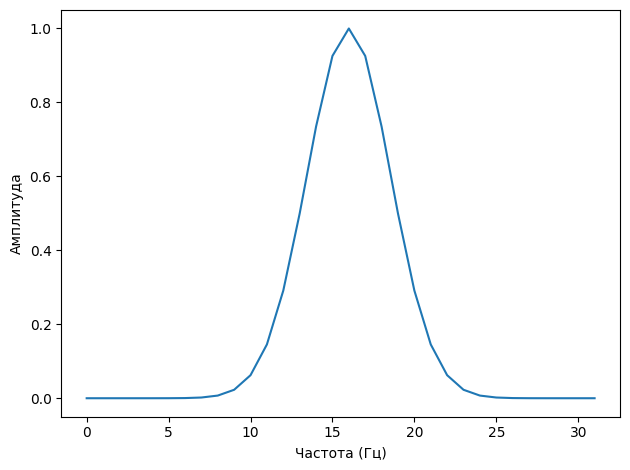

In [5]:
N = len(gaussian)
fft_rolled = np.roll(fft_gaussian, N//2)
plt.plot(abs(fft_rolled))
tk.decorate(xlabel='Частота (Гц)', ylabel='Амплитуда')

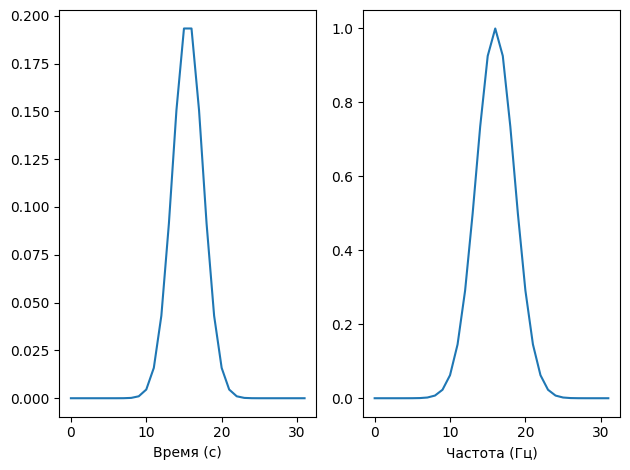

In [6]:
def plot_gaussian(std):
    M = 32
    gaussian = scipy.signal.windows.gaussian(M=M, std=std)
    gaussian /= sum(gaussian)

    plt.subplot(1, 2, 1)
    plt.plot(gaussian)
    tk.decorate(xlabel='Время (с)')

    fft_gaussian = np.fft.fft(gaussian)
    fft_rolled = np.roll(fft_gaussian, M//2)

    plt.subplot(1, 2, 2)
    plt.plot(np.abs(fft_rolled))
    tk.decorate(xlabel='Частота (Гц)')
    plt.show()

plot_gaussian(2)

## Задание 8.3

In [7]:
signal = tk.SquareSignal(freq=440)
wave = signal.make_wave(duration=1.0, framerate=100000)
wave.make_audio()

In [8]:
M = 15
std = 2.5

gaussian = scipy.signal.windows.gaussian(M=M, std=std)
bartlett = np.bartlett(M)
blackman = np.blackman(M)
hamming = np.hamming(M)
hanning = np.hanning(M)

windows = [blackman, gaussian, hanning, hamming]
names = ['Блэкман', 'Гаусс', 'Ханн', 'Хэмминг']

for window in windows:
    window /= sum(window)

windows

[array([-2.36016799e-18,  3.29842690e-03,  1.53832354e-02,  4.02486435e-02,
         7.80923397e-02,  1.21418916e-01,  1.56524425e-01,  1.70068027e-01,
         1.56524425e-01,  1.21418916e-01,  7.80923397e-02,  4.02486435e-02,
         1.53832354e-02,  3.29842690e-03, -2.36016799e-18]),
 array([0.0031742 , 0.00898051, 0.02165111, 0.04448076, 0.07787124,
        0.11617024, 0.14768132, 0.15998126, 0.14768132, 0.11617024,
        0.07787124, 0.04448076, 0.02165111, 0.00898051, 0.0031742 ]),
 array([0.        , 0.00707365, 0.02689359, 0.05553422, 0.08732292,
        0.11596356, 0.13578349, 0.14285714, 0.13578349, 0.11596356,
        0.08732292, 0.05553422, 0.02689359, 0.00707365, 0.        ]),
 array([0.0104712 , 0.01643381, 0.03314067, 0.05728277, 0.08407849,
        0.10822059, 0.12492744, 0.13089005, 0.12492744, 0.10822059,
        0.08407849, 0.05728277, 0.03314067, 0.01643381, 0.0104712 ])]

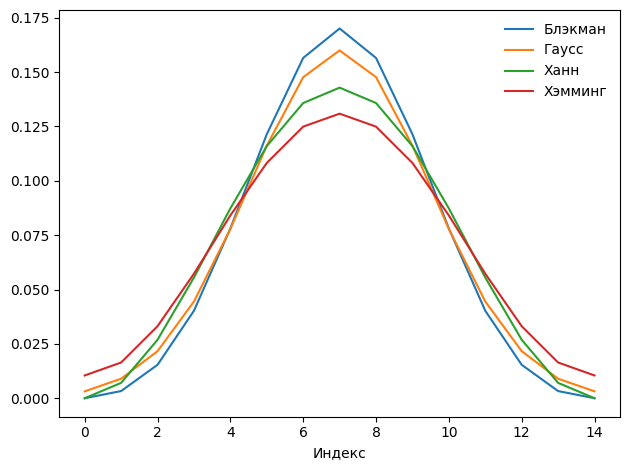

In [9]:
for window, name in zip(windows, names):
    plt.plot(window, label=name)

tk.decorate(xlabel='Индекс')

In [10]:
def zero_pad(array, n):
    res = np.zeros(n)
    res[:len(array)] = array
    return res

In [11]:
def plot_window_dfts(windows, names):
    for window, name in zip(windows, names):
        padded =  zero_pad(window, len(wave))
        dft_window = np.fft.rfft(padded)
        plt.plot(abs(dft_window), label=name)

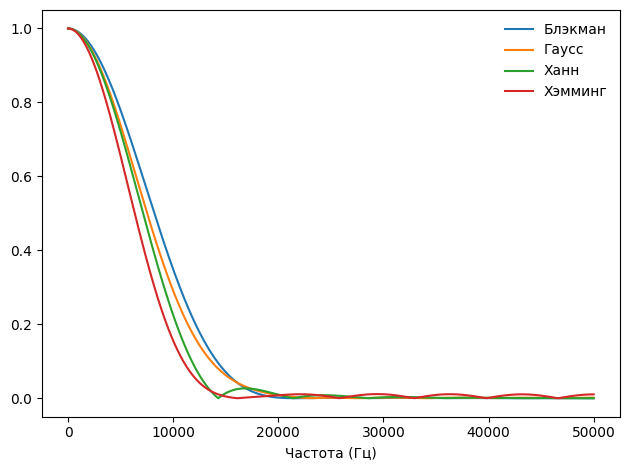

In [12]:
plot_window_dfts(windows, names)
tk.decorate(xlabel='Частота (Гц)')

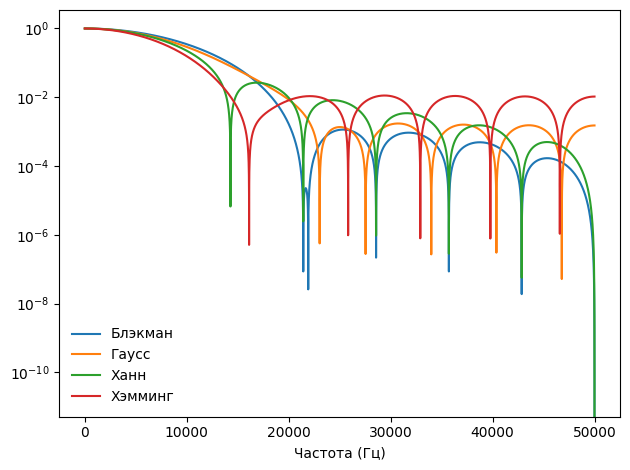

In [13]:
plot_window_dfts(windows, names)
tk.decorate(xlabel='Частота (Гц)', yscale='log')